# Distance Metrics and the Euclidean Algorithm

### A teaching notebook unifying the Euclidean Algorithm, Manhattan Distance, and Minkowski Distance

This notebook connects three mathematical ideas that, despite being separated by more than two
thousand years of history, share a common thread: the formal notion of *distance* and
*divisibility*. We trace the ancient **Euclidean Algorithm** for computing the greatest common
divisor, examine the **Manhattan distance** as a practical grid-based metric, and show how the
**Minkowski distance** generalises both into a single tunable framework. Every concept is
demonstrated with running code rather than just stated.

**Roadmap**

1. The Euclidean Algorithm — history, core identity, and a worked trace
2. Proof sketch of correctness and termination; the Extended Euclidean Algorithm
3. Manhattan distance (the $L^1$ metric) and taxicab geometry
4. Minkowski distance (the $L^p$ metric) — unifying Euclidean and Manhattan
5. Visual comparison of unit "circles" under different metrics
6. A unified comparison table and practical guidance


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. The Euclidean Algorithm

### 1.1 Historical Background

The Euclidean Algorithm is among the oldest algorithms in mathematics, described by Euclid
(circa 300 BC) in Books VII and X of the *Elements*, though it likely predates him. Indian
astronomer Aryabhata (5th century AD) used a related method, the "pulverizer", for solving
Diophantine equations. In 1844, Gabriel Lamé proved a worst-case complexity bound tied to the
Fibonacci sequence — making this the first algorithm in history to have its complexity formally
analysed.

### 1.2 Core Identity

The algorithm rests on a single recursive identity:

$$
\gcd(a, b) = \gcd(b,\; a \bmod b)
$$

This states that the GCD of $a$ and $b$ equals the GCD of $b$ and the remainder of $a$ divided by
$b$. Repeated application shrinks the problem until the remainder reaches zero, at which point the
other number *is* the GCD.


In [2]:
def gcd_trace(a, b):
    """Returns the full step-by-step trace of the Euclidean Algorithm."""
    steps = []
    while b != 0:
        q, r = divmod(a, b)
        steps.append({"a": a, "b": b, "quotient": q, "remainder": r})
        a, b = b, r
    return steps, a

steps, result = gcd_trace(1071, 462)
trace_df = pd.DataFrame(steps)
trace_df["equation"] = trace_df.apply(
    lambda row: f"{row['a']} = {row['quotient']} * {row['b']} + {row['remainder']}", axis=1
)
print(f"gcd(1071, 462) = {result}\n")
trace_df[["equation"]]


gcd(1071, 462) = 21



,equation
0,1071 = 2 * 462 + 147
1,462 = 3 * 147 + 21
2,147 = 7 * 21 + 0


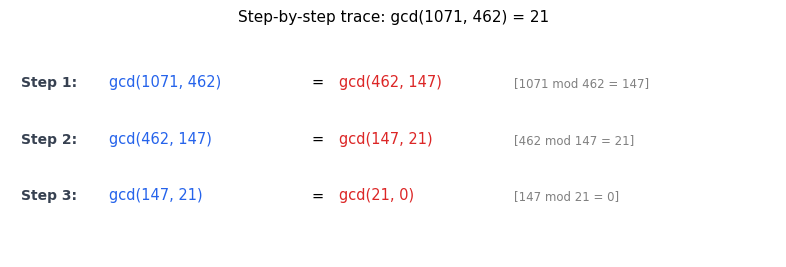

In [3]:
fig, ax = plt.subplots(figsize=(8, 0.6 * len(steps) + 1))
ax.axis("off")
for i, row in enumerate(steps):
    y = len(steps) - i
    ax.text(0.02, y, f"Step {i+1}:", fontsize=10, weight="bold", color="#374151")
    ax.text(0.18, y, f"gcd({row['a']}, {row['b']})", fontsize=10.5, color="#2563eb")
    ax.text(0.55, y, "=", fontsize=10.5)
    ax.text(0.60, y, f"gcd({row['b']}, {row['remainder']})", fontsize=10.5, color="#dc2626")
    ax.text(0.92, y, f"[{row['a']} mod {row['b']} = {row['remainder']}]", fontsize=8.5, color="gray")

ax.set_xlim(0, 1.4)
ax.set_ylim(0, len(steps) + 1)
ax.set_title(f"Step-by-step trace: gcd(1071, 462) = {result}", fontsize=11)
plt.tight_layout()
plt.show()


### 1.3 Proof Sketch: Termination and Correctness

**Termination.** The sequence of remainders $r_0 > r_1 > r_2 > \cdots \ge 0$ is strictly
decreasing and bounded below by zero. Since no infinite strictly decreasing sequence of
non-negative integers exists, the algorithm must terminate after finitely many steps.

**Correctness.** At termination, the last non-zero remainder $r_{n-1}$ divides every prior
remainder by back-substitution, and therefore divides both original numbers $a$ and $b$. Any
common divisor of $a$ and $b$ must also divide every remainder in the sequence (since each
remainder is a linear combination of the previous two). Hence $r_{n-1}$ is exactly $\gcd(a,b)$ —
no larger common divisor can exist.

### 1.4 The Extended Euclidean Algorithm

The extended version additionally finds integers $s,t$ (the **Bézout coefficients**) such that:

$$
\gcd(a,b) = s\cdot a + t\cdot b
$$

This identity underlies modular-inverse computation in RSA cryptography, the Chinese Remainder
Theorem, and the general solution of linear Diophantine equations $ax+by=c$.


In [4]:
def extended_gcd(a, b):
    old_s, s = 1, 0
    old_t, t = 0, 1
    old_r, r = a, b
    while r != 0:
        q = old_r // r
        old_r, r = r, old_r - q * r
        old_s, s = s, old_s - q * s
        old_t, t = t, old_t - q * t
    return old_r, old_s, old_t

g, s, t = extended_gcd(1071, 462)
print(f"gcd(1071, 462) = {g}")
print(f"Bezout coefficients: s={s}, t={t}")
print(f"Check: {s}*1071 + {t}*462 = {s*1071 + t*462}")


gcd(1071, 462) = 21
Bezout coefficients: s=-3, t=7
Check: -3*1071 + 7*462 = 21


### 1.5 Complexity

Lamé's theorem (1844) bounds the number of steps: for $b < 10^d$, the algorithm requires at most
roughly $1.44\,d$ steps — i.e. $O(\log b)$ overall. The worst case occurs precisely when $a$ and
$b$ are consecutive Fibonacci numbers, since each step then reduces the pair as slowly as
possible.


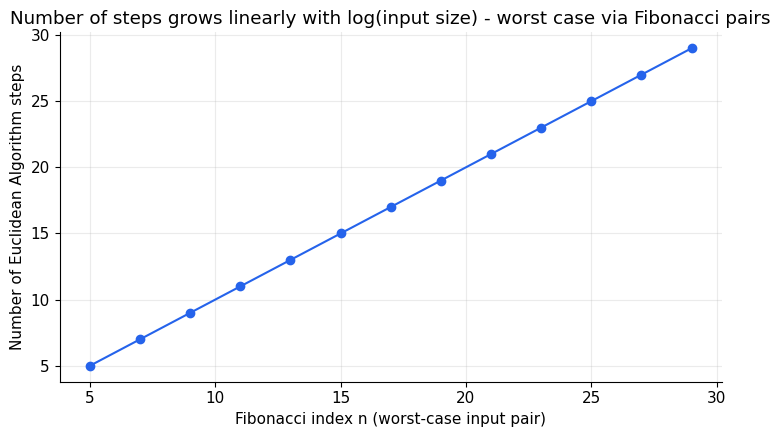

In [5]:
def fib_pair(n):
    a, b = 1, 1
    for _ in range(n):
        a, b = b, a + b
    return b, a  # consecutive Fibonacci numbers

ns = range(5, 31, 2)
step_counts = []
for n in ns:
    a, b = fib_pair(n)
    s, _ = gcd_trace(a, b)
    step_counts.append(len(s))

plt.figure(figsize=(7.5, 4.5))
plt.plot(list(ns), step_counts, "o-", color="#2563eb")
plt.xlabel("Fibonacci index n (worst-case input pair)")
plt.ylabel("Number of Euclidean Algorithm steps")
plt.title("Number of steps grows linearly with log(input size) - worst case via Fibonacci pairs")
plt.tight_layout()
plt.show()


## 2. Manhattan Distance (the $L^1$ Metric)

### 2.1 Background

Roger Boscovich used the $L^1$ norm for regression as early as 1757. Hermann Minkowski and
Frigyes Riesz formally studied $L^p$ spaces around 1910. Karl Menger coined the term "taxicab
geometry" in 1952. The name "Manhattan distance" comes from Manhattan's grid-like street layout,
where travel is restricted to horizontal and vertical moves — no diagonal shortcuts.

$$
d_1(x,y) = \sum_i |x_i - y_i|
$$

It satisfies all the requirements of a true metric — non-negativity, symmetry, and the triangle
inequality — each following directly from the corresponding property of the absolute value.


In [6]:
def manhattan(p1, p2):
    return sum(abs(a - b) for a, b in zip(p1, p2))

def euclidean(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

p1, p2 = (1, 2), (4, 6)
print(f"Manhattan distance from {p1} to {p2}: {manhattan(p1, p2)}")
print(f"Euclidean distance from {p1} to {p2}: {euclidean(p1, p2):.3f}")


Manhattan distance from (1, 2) to (4, 6): 7
Euclidean distance from (1, 2) to (4, 6): 5.000


### 2.2 The "Taxicab Circle"

Under the Manhattan metric, the set of points at unit distance from the origin is not a round
circle but a rotated square (a diamond). This single picture explains a great deal about why
Manhattan distance behaves differently from Euclidean distance in practice.


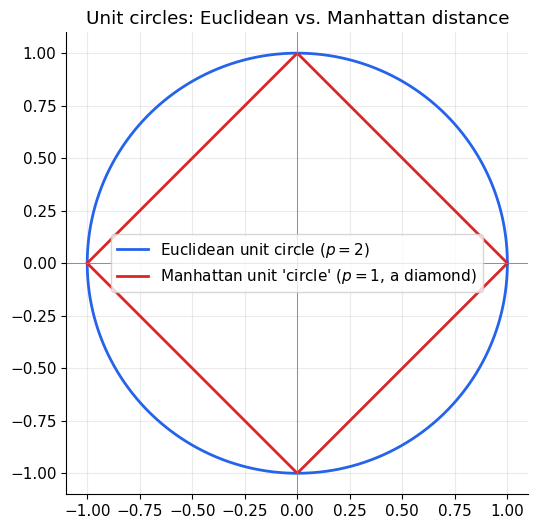

In [7]:
theta = np.linspace(0, 2 * np.pi, 400)

# Euclidean unit circle
ex, ey = np.cos(theta), np.sin(theta)

# Manhattan unit "circle" (diamond): |x| + |y| = 1
t = np.linspace(-1, 1, 200)
mx = np.concatenate([t, t[::-1]])
my = np.concatenate([1 - np.abs(t), -(1 - np.abs(t[::-1]))])

plt.figure(figsize=(5.5, 5.5))
plt.plot(ex, ey, label="Euclidean unit circle ($p=2$)", color="#2563eb", linewidth=2)
plt.plot(mx, my, label="Manhattan unit 'circle' ($p=1$, a diamond)", color="#dc2626", linewidth=2)
plt.axhline(0, color="gray", linewidth=0.6); plt.axvline(0, color="gray", linewidth=0.6)
plt.gca().set_aspect("equal")
plt.legend()
plt.title("Unit circles: Euclidean vs. Manhattan distance")
plt.tight_layout()
plt.show()


**Applications of Manhattan distance.** A* pathfinding on grid-based maps and games; $k$-NN
classification, where it is often more robust to outliers in high dimensions than Euclidean
distance; LASSO regression, where the $L^1$ penalty promotes sparsity; and compressed sensing.


## 3. Minkowski Distance: A Unifying Framework

Hermann Minkowski generalised both metrics above into a single parameterised family:

$$
d_p(x,y) = \Big(\sum_i |x_i - y_i|^p\Big)^{1/p}
$$

- $p=1$ recovers the **Manhattan** distance (diamond-shaped unit ball).
- $p=2$ recovers the **Euclidean** distance (circular unit ball).
- $p\to\infty$ recovers the **Chebyshev** distance, $\max_i |x_i-y_i|$ (square-shaped unit ball).


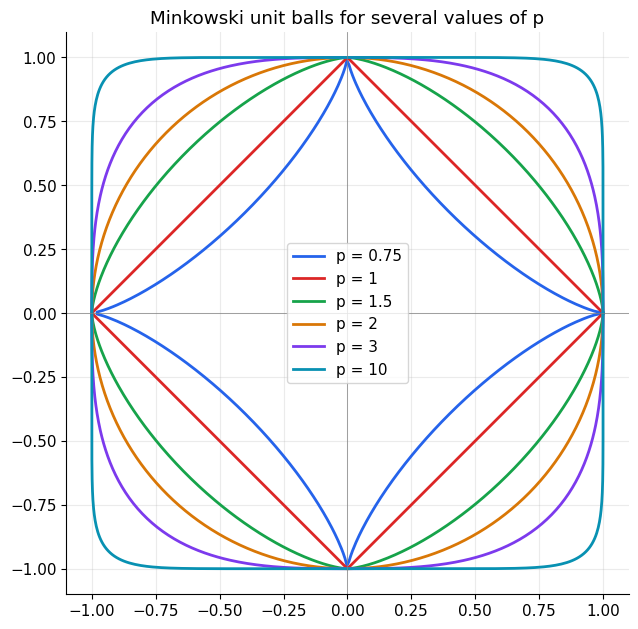

In [8]:
def minkowski(p1, p2, p):
    if p == np.inf:
        return max(abs(a - b) for a, b in zip(p1, p2))
    return sum(abs(a - b) ** p for a, b in zip(p1, p2)) ** (1 / p)

p_values = [0.75, 1, 1.5, 2, 3, 10]
fig, ax = plt.subplots(figsize=(6.5, 6.5))

theta = np.linspace(0, 2 * np.pi, 800)
for p, c in zip(p_values, COLORS):
    # Parametrise the unit ball boundary in polar-like fashion using sign(cos)/sin scaling
    ct, st = np.cos(theta), np.sin(theta)
    denom = (np.abs(ct) ** p + np.abs(st) ** p) ** (1 / p)
    r = 1.0 / denom
    ax.plot(r * ct, r * st, label=f"p = {p}", color=c, linewidth=2)

ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.legend()
ax.set_title("Minkowski unit balls for several values of p")
plt.tight_layout()
plt.show()


As $p$ increases from $1$ toward $\infty$, the unit ball morphs continuously from a diamond,
through a circle at $p=2$, toward an increasingly square shape — visually demonstrating that
Euclidean and Manhattan distances are simply two snapshots of one continuous family.


## 4. Numerical Comparison Across Metrics

We compute Euclidean, Manhattan, and several Minkowski distances for a handful of representative
point pairs, to make the size differences between metrics concrete.


In [9]:
pairs = [((0, 0), (3, 4)), ((1, 1), (4, 5)), ((0, 0), (2, 2)), ((-1, 2), (3, -2))]
p_list = [1, 1.5, 2, 3, np.inf]

rows = []
for p1, p2 in pairs:
    row = {"Point A": p1, "Point B": p2}
    for p in p_list:
        label = "Chebyshev (p=inf)" if p == np.inf else f"p={p}"
        row[label] = round(minkowski(p1, p2, p), 3)
    rows.append(row)

dist_table = pd.DataFrame(rows)
dist_table


,Point A,Point B,p=1,p=1.5,p=2,p=3,Chebyshev (p=inf)
0,"(0, 0)","(3, 4)",7.0,5.584,5.000,4.498,4
1,"(1, 1)","(4, 5)",7.0,5.584,5.000,4.498,4
2,"(0, 0)","(2, 2)",4.0,3.175,2.828,2.520,2
3,"(-1, 2)","(3, -2)",8.0,6.350,5.657,5.040,4


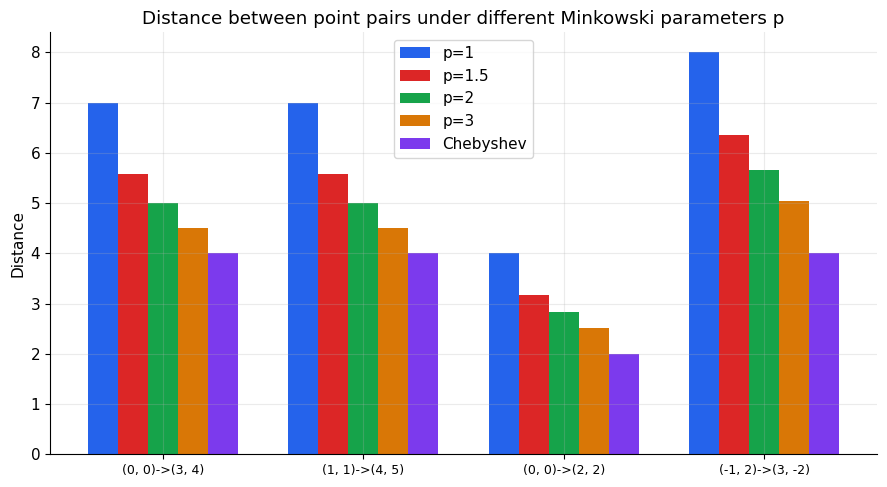

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(pairs))
width = 0.15
for i, p in enumerate(p_list):
    label = "Chebyshev" if p == np.inf else f"p={p}"
    values = [minkowski(p1, p2, p) for p1, p2 in pairs]
    ax.bar(x_pos + i * width, values, width=width, label=label, color=COLORS[i])

ax.set_xticks(x_pos + width * (len(p_list) - 1) / 2)
ax.set_xticklabels([f"{a}->{b}" for a, b in pairs], fontsize=9)
ax.set_ylabel("Distance")
ax.set_title("Distance between point pairs under different Minkowski parameters p")
ax.legend()
plt.tight_layout()
plt.show()


Larger $p$ values weight large coordinate-wise differences more heavily and increasingly approach
the maximum single-axis difference (Chebyshev distance), while smaller $p$ values weight all
differences more evenly, which is part of why $L^1$-style metrics tend to be more robust to
outliers in any single coordinate.


## 5. Unified Comparison and Practical Guidance

| Aspect | Euclidean ($p=2$) | Manhattan ($p=1$) | Minkowski (general $p$) |
|---|---|---|---|
| Formula | $\sqrt{\sum (x_i-y_i)^2}$ | $\sum |x_i-y_i|$ | $\big(\sum |x_i-y_i|^p\big)^{1/p}$ |
| Geometry | Round circles | Diamond shapes | $p<2$: diamond-like; $p>2$: square-like |
| Outlier sensitivity | Quadratic (amplifies outliers) | Linear (more robust) | Tunable via $p$ |
| Best for | Physics, continuous spaces, image pixels | Grids, sparse high-dimensional data, $k$-NN | Flexible experimentation; $p$ as a hyperparameter |

**Unifying principle.** Euclidean distance *is* Minkowski distance with $p=2$. Manhattan distance
*is* Minkowski distance with $p=1$. The Minkowski family is therefore the most general and
flexible of the three, offering a single continuous knob that interpolates between — and beyond —
the two classical special cases.


## 6. Conclusion

This notebook traced a single unifying thread through three mathematical ideas spanning more than
two thousand years: the Euclidean Algorithm computes the GCD of two integers with a provably
optimal $O(\log n)$ number of steps; the Manhattan distance offers a practical, outlier-robust
metric for grid-structured and high-dimensional problems; and the Minkowski distance shows that
both Euclidean and Manhattan distances are simply two points along one continuous parameterised
family. Together, they illustrate how ancient algorithms can remain computationally optimal,
how simple geometric intuitions (taxicab geometry) power modern search algorithms, and how a
single parameter can unify seemingly distinct mathematical tools.

**References**

- Euclid (c. 300 BC). *Elements*, Books VII and X.
- Lamé, G. (1844). *Note sur la limite du nombre des divisions dans la recherche du plus grand commun diviseur.*
- Minkowski, H. (1910). Collected works on $L^p$ spaces and the geometry of numbers.
- Krause, E. F. (1986). *Taxicab Geometry: An Adventure in Non-Euclidean Geometry.* Dover Publications.
